In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("titanic.csv")

In [4]:
df.head()

,Cabin,Ticket,number,Survived
0,NaN,A/5 21171,5,0
1,C85,PC 17599,3,1
2,NaN,STON/O2. 3101282,6,1
3,C123,113803,3,1
4,NaN,373450,A,0


In [5]:
df.isnull().sum()

Cabin       687
Ticket        0
number        0
Survived      0
dtype: int64

In [7]:
df["Cabin"].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

In [8]:
df["Ticket"].unique()

array(['A/5 21171', 'PC 17599', 'STON/O2. 3101282', '113803', '373450',
       '330877', '17463', '349909', '347742', '237736', 'PP 9549',
       '113783', 'A/5. 2151', '347082', '350406', '248706', '382652',
       '244373', '345763', '2649', '239865', '248698', '330923', '113788',
       '347077', '2631', '19950', '330959', '349216', 'PC 17601',
       'PC 17569', '335677', 'C.A. 24579', 'PC 17604', '113789', '2677',
       'A./5. 2152', '345764', '2651', '7546', '11668', '349253',
       'SC/Paris 2123', '330958', 'S.C./A.4. 23567', '370371', '14311',
       '2662', '349237', '3101295', 'A/4. 39886', 'PC 17572', '2926',
       '113509', '19947', 'C.A. 31026', '2697', 'C.A. 34651', 'CA 2144',
       '2669', '113572', '36973', '347088', 'PC 17605', '2661',
       'C.A. 29395', 'S.P. 3464', '3101281', '315151', 'C.A. 33111',
       'S.O.C. 14879', '2680', '1601', '348123', '349208', '374746',
       '248738', '364516', '345767', '345779', '330932', '113059',
       'SO/C 14885', '31012

In [9]:
df["number"].unique()

array(['5', '3', '6', 'A', '2', '1', '4'], dtype=object)

Text(0.5, 1.0, 'travling with members')

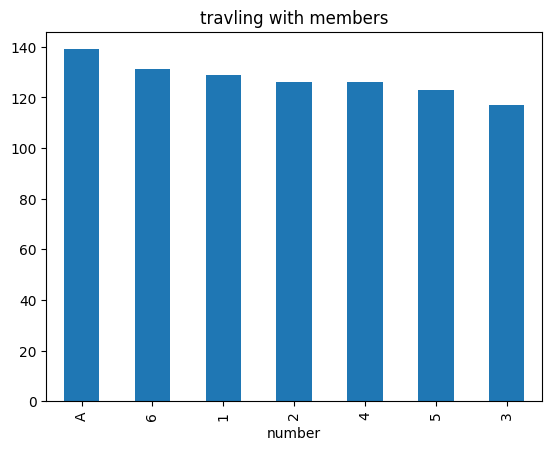

In [21]:
fig = df["number"].value_counts().plot(kind="bar")
fig.set_title("travling with members")

In [22]:
# first handle "number" column
# and extracting numerical part from the number column
df["number_num"] = pd.to_numeric(df["number"], errors="coerce", downcast="integer")

In [24]:
df["number_num"].head()

0    5.0
1    3.0
2    6.0
3    3.0
4    NaN
Name: number_num, dtype: float64

In [26]:
# extracting categorical part from the number column
df["number_cat"] = np.where(df["number_num"].isnull(), df["number"], np.nan)

In [27]:
df["number_cat"]

0      NaN
1      NaN
2      NaN
3      NaN
4        A
      ... 
886    NaN
887    NaN
888    NaN
889    NaN
890    NaN
Name: number_cat, Length: 891, dtype: object

In [34]:
df.sample(5)

,Cabin,Ticket,number,Survived,number_num,number_cat
431,NaN,376564,4,1,4.0,NaN
412,C78,19928,2,1,2.0,NaN
355,NaN,345783,4,0,4.0,NaN
531,NaN,2641,A,0,NaN,A
238,NaN,28665,A,0,NaN,A


In [36]:
# now extracting the numerical and categorical parts from "Cabin" column.
df["cabin_num"] = df["Cabin"].str.extract("(\d+)")

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\kumar\AppData\Local\Temp\ipykernel_16236\2592289679.py:2: SyntaxWarning: invalid escape sequence '\d'
  df["cabin_num"] = df["Cabin"].str.extract("(\d+)")


In [37]:
df["cabin_cat"] = df["Cabin"].str[0]

In [38]:
df.head()

,Cabin,Ticket,number,Survived,number_num,number_cat,cabin_num,cabin_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN
1,C85,PC 17599,3,1,3.0,NaN,85,C
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN
3,C123,113803,3,1,3.0,NaN,123,C
4,NaN,373450,A,0,NaN,A,NaN,NaN


In [41]:
# extracting the numerical and categorical parts from the "Ticket" column

In [49]:
# extract the second part of the cabin column as numerical column
df["Ticket_num"] = df["Ticket"].apply(lambda s:s.split()[-1])

In [50]:
type(df["Ticket_num"])

pandas.core.series.Series

In [51]:
df["Ticket_num"] = pd.to_numeric(df["Ticket_num"], errors="coerce", downcast="integer")

In [52]:
df["Ticket_num"]

0        21171.0
1        17599.0
2      3101282.0
3       113803.0
4       373450.0
         ...    
886     211536.0
887     112053.0
888       6607.0
889     111369.0
890     370376.0
Name: Ticket_num, Length: 891, dtype: float64

In [53]:
# extract the first part of the cabin column as numerical column
df["Ticket_cat"] = df["Ticket"].apply(lambda s:s.split()[0])

In [54]:
df.head()

,Cabin,Ticket,number,Survived,number_num,number_cat,cabin_num,cabin_cat,Ticket_num,Ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,113803
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,373450


In [56]:
df["Ticket_cat"] = np.where(df["Ticket_cat"].str.isdigit(), np.nan, df["Ticket_cat"])

In [57]:
df.head()

,Cabin,Ticket,number,Survived,number_num,number_cat,cabin_num,cabin_cat,Ticket_num,Ticket_cat
0,NaN,A/5 21171,5,0,5.0,NaN,NaN,NaN,21171.0,A/5
1,C85,PC 17599,3,1,3.0,NaN,85,C,17599.0,PC
2,NaN,STON/O2. 3101282,6,1,6.0,NaN,NaN,NaN,3101282.0,STON/O2.
3,C123,113803,3,1,3.0,NaN,123,C,113803.0,NaN
4,NaN,373450,A,0,NaN,A,NaN,NaN,373450.0,NaN
